# 第 4 章实验｜用概率预测下个月是否违约

适用：本科三年级，课堂核心实验约 20–30 分钟；拓展可课后完成。

## 目标（Goal）与来源

[scikit-learn 官方示例](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)；原版存于 `materials/upstream/sklearn/`，版本、SHA-256 和下载日期见 `manifest-extra.json`。原代码作者为 The scikit-learn developers，BSD-3-Clause，许可见同目录 `COPYING`。

<strong>复用与改动说明：</strong> 原版分类器对比代码保存在可选附录辅助文件；唯一模型适配是 GaussianProcessClassifier 设置 optimizer=None（原版在本环境优化器异常退出并产生数值警告，固定原有核参数保证可读边界），其余主体不变；新增逻辑回归（Logistic regression）与阈值（Threshold）实验。 图表标签保留英文以避免字体依赖，中文用于讲解与问题。下方“课程补充”不是上游原版。

## 准备（Setup）

从项目根目录启动 Jupyter，选择课程 Python 内核。依赖安装见项目 README。本实验仅 CPU，不需要 GPU、账号或下载数据；固定随机种子。先读代码，再运行所有单元。
**本版主线先只学一个逻辑回归模型**：数据→划分→训练→概率→阈值→验证选择→一次测试。官方十模型大图移到最后可选附录。


## 1｜准确率80%可能什么都没做到吗？

本数据中违约约占 22.1%。先只看类别比例，再用全猜未违约建立基线。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_candidates = [
    Path("data") / "default of credit card clients.csv",
    Path("../../04-classification-probability/notebook/data") / "default of credit card clients.csv",
    Path("lessons/04-classification-probability/notebook/data") / "default of credit card clients.csv",
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("请按 notebook/README.md 将 UCI 数据文件放在本目录的 data 文件夹中")

credit = pd.read_csv(data_path, header=1, index_col=0)
feature_names = [
    "LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3",
    "BILL_AMT1", "BILL_AMT2", "PAY_AMT1", "PAY_AMT2",
]
X_cls = credit[feature_names].copy()
y_cls = credit["default payment next month"].astype(int)
print("数据来源：UCI 信用卡违约数据（2005年）")
print("特征与标签形状:", X_cls.shape, y_cls.shape)
print("类别计数（未违约 0、违约 1）:", np.bincount(y_cls))

数据来源：UCI 信用卡违约数据（2005年）
特征与标签形状: (30000, 8) (30000,)
类别计数（未违约 0、违约 1）: [23364  6636]


本章使用 UCI「信用卡客户违约」真实数据（2005年）。每行是一名客户，标签记录其下个月是否违约。原数据有 30,000 行和 23 个特征；本实验选取 8 个额度、还款状态、账单金额与还款金额特征，不使用客户编号和人口属性。数据只用于教学复现实验，不代表当前信贷决策表现。

数据文件已随课程保存，可离线运行。来源、引用与 CC BY 4.0 许可见本目录 `data/README.md`。

<strong>停一下，检查：</strong> 如果把所有客户都预测为 0，正类召回率是多少？

<details><summary>查看解释</summary>

0。多数类准确率约为 78%，仍会漏掉全部违约客户。

</details>

## 2｜哪些数据可以用来作决定？

保留训练、验证、测试三份。先检查大小，暂时不查看测试表现。


In [2]:
from sklearn.model_selection import train_test_split
X_dev, X_final, y_dev, y_final = train_test_split(
    X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=42)
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=42)
print("训练、验证、测试:", len(y_fit), len(y_valid), len(y_final))


训练、验证、测试: 18000 6000 6000


得到训练 18,000、验证 6,000、测试 6,000。分层抽样尽量保持各份数据中的违约比例。最终测试集只在方案冻结后使用。

## 3｜从概率到 Logistic 回归：odds → logit → sigmoid

二分类中，令 p=P(Y=1) 表示正类发生的概率。几率（odds）比较发生与不发生：odds=p/(1−p)，反过来 p=odds/(1+odds)。

| 事件 | p | 1−p | odds |
|---|---:|---:|---:|
| 抛硬币为正面 | 0.5 | 0.5 | 1 |
| 掷骰子出 6 | 1/6 | 5/6 | 0.2 |
| 下雨（假设） | 0.8 | 0.2 | 4 |
| 中奖（假设） | 0.01 | 0.99 | 约 0.0101 |

例如 p=0.5 时 odds=1；p=0.75 时 odds=3。注意 odds ratio（优势比/几率比）是两个 odds 的比，不是单个 odds。

对 odds 取自然对数，得到对数几率（log-odds），也叫 logit：logit(p)=ln[p/(1−p)]，取值范围是整个实数轴。Logistic 回归令条件概率 p(x)=P(Y=1|x) 满足 logit(p(x))=wᵀx+b=z；反解便得到 p(x)=1/[1+exp(−z)]，也就是 Logistic sigmoid。模型对概率的 log-odds 建模，不是直接对 0/1 标签做普通线性回归。

现在训练一个模型：先将缩放和 Logistic 回归放进 Pipeline。

In [3]:
# [ref:odds-logit]
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
logistic = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
logistic.fit(X_fit, y_fit)
print("学到的系数形状:", logistic[-1].coef_.shape)


学到的系数形状: (1, 8)


缩放器仅在X_fit拟合。系数形状(1,8)：这里是二分类的一组8维权重，另有截距。

<strong>停一下，检查：</strong> predict_proba会重新学习验证集的均值吗？

<details><summary>查看解释</summary>

不会；Pipeline使用训练时保存的缩放统计量。

</details>


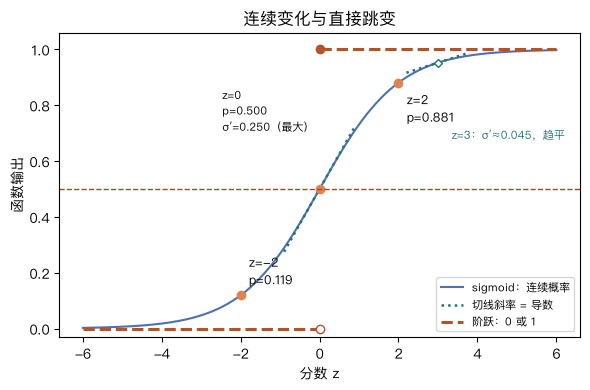

In [4]:
# [ref:sigmoid-step]
# sigmoid 与硬阶跃：训练时的连续输出，预测时仍可阈值分类。
# 小结：z 越大概率越接近 1；z=0 恰好 0.5；三个标注点与手算一致
# 图内标签含中文：指定中文字体（macOS 为 PingFang SC，其余按序回退），并禁用 Unicode 负号
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
zz = np.linspace(-6, 6, 300)
pp = 1 / (1 + np.exp(-zz))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(zz, pp, color="#4C72B0", label="sigmoid：连续概率")
# 切线斜率就是 sigmoid 导数：中心较大，尾部较小。
ax.plot([-0.9, 0.9], [0.275, 0.725], color="#23756c", linestyle=":", linewidth=1.8, label="切线斜率 = 导数")
z_tail = 3.0
p_tail = 1 / (1 + np.exp(-z_tail))
slope_tail = p_tail * (1 - p_tail)
tail_x = np.array([2.2, 3.8])
ax.plot(tail_x, p_tail + slope_tail * (tail_x - z_tail), color="#23756c", linestyle=":", linewidth=1.8)
ax.plot(z_tail, p_tail, marker="D", markersize=4, markerfacecolor="white", markeredgecolor="#23756c")
ax.plot([-6, 0], [0, 0], color="#B4532A", linestyle="--", linewidth=2.2, label="阶跃：0 或 1")
ax.plot([0, 6], [1, 1], color="#B4532A", linestyle="--", linewidth=2.2)
ax.plot(0, 0, "o", color="#B4532A", markerfacecolor="white")
ax.plot(0, 1, "o", color="#B4532A")
for z0 in (-2, 0, 2):           # 三个标注点：与手算一致
    p0 = 1 / (1 + np.exp(-z0))
    ax.plot(z0, p0, "o", color="#DD8452")
    if z0 == 0:
        ax.annotate(f"z=0\np={p0:.3f}\nσ′={p0 * (1 - p0):.3f}（最大）", (z0, p0),
                    textcoords="offset points", xytext=(-70, 42), fontsize=8)
    else:
        ax.annotate(f"z={z0}\np={p0:.3f}", (z0, p0),
                    textcoords="offset points", xytext=(6, -28) if z0 == 2 else (6, 8), fontsize=9)
ax.text(3.35, 0.68, f"z=3：σ′≈{slope_tail:.3f}，趋平", fontsize=8, color="#23756c")
ax.axhline(0.5, color="#a14a22", linestyle="--", linewidth=1)
ax.legend(loc="lower right", fontsize=8)
ax.set(xlabel="分数 z", ylabel="函数输出", title="连续变化与直接跳变",
       ylim=(-0.03, 1.06))
plt.tight_layout()
from pathlib import Path
cwd = Path.cwd()
notebook_dir = cwd if (cwd / "helpers").exists() else cwd / "lessons/04-classification-probability/notebook"
asset_dir = notebook_dir.parent / "assets"
asset_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(asset_dir / "lab03-sigmoid.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

## 4｜概率怎样变成类别？

先观察前五个概率，然后用0.5阈值把概率转为违约/未违约预测。


In [5]:
valid_proba = logistic.predict_proba(X_valid)[:, 1]
pred_half = (valid_proba >= 0.5).astype(int)
display(pd.DataFrame({
    "p(default)": valid_proba[:5],
    "prediction@0.5": np.where(pred_half[:5] == 1, "default", "no default"),
    "actual": np.where(y_valid.iloc[:5].to_numpy() == 1, "default", "no default"),
}))

,p(default),prediction@0.5,actual
0,0.247267,no default,default
1,0.138960,no default,no default
2,0.053589,no default,default
3,0.100344,no default,no default
4,0.092196,no default,no default


[:,1]取类别1的概率列。阈值是决策规则；改阈值不需要重新fit。概率估计也不自动等于已校准置信度。

<strong>停一下，检查：</strong> 0.49与0.51的样本很相近，为什么类别不同？

<details><summary>查看解释</summary>

0.5阈值把连续分数离散化；类别边界由规则决定。

</details>


## 5｜先算一个阈值的错误代价

设漏报FN代价是误报FP的4倍。先把混淆矩阵读懂，再写循环。


In [6]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
matrix = confusion_matrix(y_valid, pred_half)
tn, fp, fn, tp = matrix.ravel()
print(matrix)
print("TN FP FN TP:", tn, fp, fn, tp)
print("假设代价 FP+4FN:", fp + 4*fn)
print("查准率、召回率:", precision_score(y_valid, pred_half),
      recall_score(y_valid, pred_half))


[[4546  127]
 [1001  326]]
TN FP FN TP: 4546 127 1001 326
假设代价 FP+4FN: 4131
查准率、召回率: 0.7196467991169978 0.24566691785983422


矩阵按真实类别为行、预测为列。Precision=TP/(TP+FP)，Recall=TP/(TP+FN)；代价4是外部假设。

<strong>停一下，检查：</strong> 将阈值降低通常先希望减少哪种错误？

<details><summary>查看解释</summary>

FN漏报，因为更多样本被送复核；FP可能增加，须读实际结果。

</details>


## 6｜重复刚才的计算，比较候选阈值

现在循环只有一个职责：固定模型，逐个阈值计算验证指标。


In [7]:
rows = []
for threshold in np.arange(0.1, 0.91, 0.1):
    pred = (valid_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel()
    precision = precision_score(y_valid, pred, zero_division=0)
    recall = recall_score(y_valid, pred)
    rows.append([threshold, precision, recall, fp, fn, fp+4*fn])
threshold_table = pd.DataFrame(rows, columns=[
    "threshold", "precision", "recall", "FP", "FN", "cost=FP+4FN"])
display(threshold_table.round(3))


,threshold,precision,recall,FP,FN,cost=FP+4FN
0,0.1,0.246,0.904,3673,127,4181
1,0.2,0.325,0.711,1957,384,3493
2,0.3,0.571,0.445,443,737,3391
3,0.4,0.636,0.382,290,820,3570
4,0.5,0.720,0.246,127,1001,4131
5,0.6,0.683,0.106,65,1187,4813
6,0.7,0.667,0.038,25,1277,5133
7,0.8,0.548,0.013,14,1310,5254
8,0.9,0.471,0.006,9,1319,5285


每行都来自同一 6,000 人验证集。zero_division=0明确没有预测正类时的Precision处理。

<strong>停一下，检查：</strong> 为何不往循环中加入测试指标找最低代价？

<details><summary>查看解释</summary>

那会把测试集变成开发集，最终分数不再是独立评价。

</details>


## 7｜冻结阈值，并解释选择依据

先自己从表里找最小代价，再检查程序选中的行。


只根据验证集选定阈值: 0.3


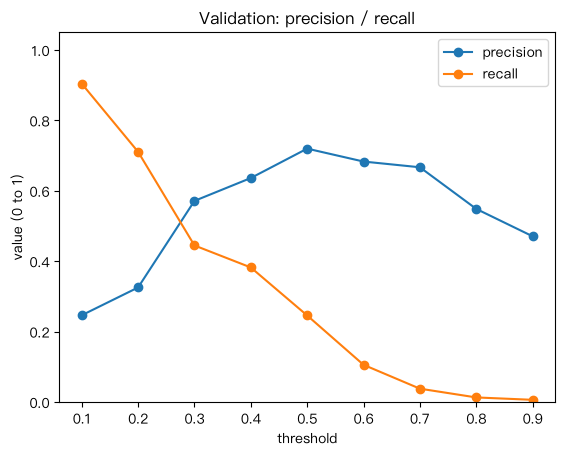

In [8]:
best_row = threshold_table["cost=FP+4FN"].idxmin()
chosen = float(threshold_table.loc[best_row, "threshold"])
print("只根据验证集选定阈值:", round(chosen, 2))
ax = threshold_table.plot(x="threshold", y=["precision", "recall"],
                          marker="o", ylim=(0, 1.05))
ax.set_ylabel("value (0 to 1)")
plt.title("Validation: precision / recall"); plt.show()


idxmin在并列时返回首次出现的行；阈值表按升序排列，因此遵循固定的并列规则。选的是假设代价，不是准确率。

<strong>停一下，检查：</strong> 漏报代价改成10后，必须重新训练模型吗？

<details><summary>查看解释</summary>

不必；可以在验证集重新选决策阈值。看过本次测试后再改方案属于开发练习，不能重称独立测试。

</details>


## 8｜先把多数类基线摆出来

在最终测试中同时报告基线。不要只展示复杂模型。


In [9]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy="most_frequent").fit(X_fit, y_fit)
print("多数类基线准确率:", round(baseline.score(X_final, y_final), 3))
print("多数类基线正类召回率:",
      recall_score(y_final, baseline.predict(X_final)))


多数类基线准确率: 0.779
多数类基线正类召回率: 0.0


基线能提醒我们：表面准确率并不等于解决复核任务。此时方案已冻结，不再根据输出换参数。

<strong>停一下，检查：</strong> 基线的训练过程学到了什么？

<details><summary>查看解释</summary>

训练标签中最常见的类别；并没有学习特征与标签的关系。

</details>


## 9｜对冻结方案做一次测试

使用已训练模型、已冻结阈值。把每个指标对应到业务问题。


准确率: 0.797
查准率: 0.5516587677725119
召回率: 0.4385832705350414
F1: 0.48866498740554154


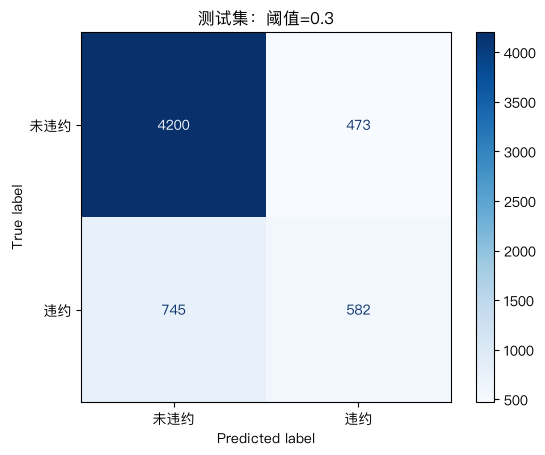

In [10]:
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
final_pred = (logistic.predict_proba(X_final)[:, 1] >= chosen).astype(int)
print("准确率:", accuracy_score(y_final, final_pred))
print("查准率:", precision_score(y_final, final_pred))
print("召回率:", recall_score(y_final, final_pred))
print("F1:", f1_score(y_final, final_pred))
ConfusionMatrixDisplay.from_predictions(
    y_final, final_pred, display_labels=["未违约", "违约"], cmap="Blues")
plt.title(f"测试集：阈值={chosen:.1f}"); plt.show()


正类=下个月违约，负类=未违约。Precision问预测违约者中有多少实际违约，Recall问实际违约者中找回了多少。F1是二者调和平均，不是业务总代价。

<strong>停一下，检查：</strong> 召回率更高就一定更值得部署吗？

<details><summary>查看解释</summary>

还要看误报、复核容量和具体代价；不能忽略任务约束。

</details>


## 主线练习与提交

先遮住答案：把验证集中的FN代价改为10，只重新计算阈值表，预测阈值变化方向。提交一张表、一个混淆矩阵和100字说明。

<details><summary>教师解释</summary>

更高漏报代价通常倾向更低阈值，但有限样本和离散候选会使最优值不变。结果必须据表报告。测试集已看过，新的方案只称开发练习。

</details>


## 拓展A｜一个模型看懂后，再比较三种边界

月牙数据不能被简单直线完美分开。这里是另一批二维合成数据；不是前面八维复核任务。


In [11]:
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
X_small, y_small = make_moons(noise=0.3, random_state=0)
a, b, c, d = train_test_split(X_small, y_small, test_size=0.4, random_state=42)
settings = [("Logistic", LogisticRegression(max_iter=1000)),
            ("kNN", KNeighborsClassifier(3)), ("Naive Bayes", GaussianNB())]
comparison_models = {}
for name, estimator in settings:
    model = make_pipeline(StandardScaler(), estimator).fit(a, c)
    comparison_models[name] = model
    print(name, "固定划分准确率:", model.score(b, d))


Logistic 固定划分准确率: 0.875
kNN 固定划分准确率: 0.975
Naive Bayes 固定划分准确率: 0.875


这里训练过程仍在课堂单元中：三种模型使用相同数据划分及训练内缩放。固定配置对照不是算法排行榜。

<strong>停一下，检查：</strong> 二维结果能证明真实任务中kNN最好吗？

<details><summary>查看解释</summary>

不能。这里只解释归纳偏好与边界形状，配置和任务都有限。

</details>


## 拓展B｜把三种模型的决策画出来

背景只画预测类别，不把颜色当校准概率。深色训练点、浅色测试点。


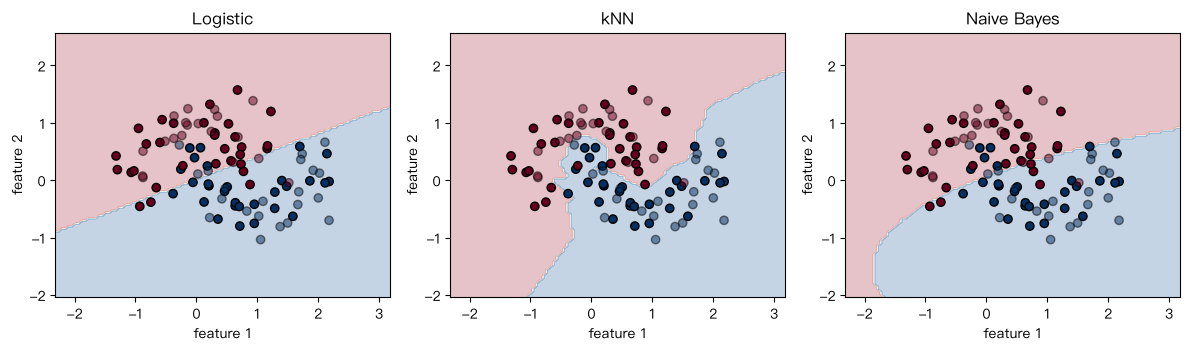

In [12]:
from sklearn.inspection import DecisionBoundaryDisplay
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (name, model) in zip(axes, comparison_models.items()):
    DecisionBoundaryDisplay.from_estimator(
        model, X_small, ax=ax, response_method="predict", alpha=0.25, cmap="RdBu")
    ax.scatter(a[:, 0], a[:, 1], c=c, cmap="RdBu", edgecolors="k")
    ax.scatter(b[:, 0], b[:, 1], c=d, cmap="RdBu", edgecolors="k", alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
plt.tight_layout(); plt.show()


逻辑回归线性分界，kNN依赖局部邻居，朴素贝叶斯由条件分布假设决定形状。复杂边界也可能追随噪声。

<strong>停一下，检查：</strong> 背景颜色是否能直接与十模型原图的响应值比较？

<details><summary>查看解释</summary>

不能。这里明确用predict，表示离散类别；原图可能使用概率或决策函数。

</details>


## 可选附录｜上游十模型全景图

课堂不要求逐行读巨幅绘图。完整上游计算和BSD署名保留在[辅助源码](helpers/step_early.py)的`official_comparison`，包含三数据集×十模型训练。GaussianProcessClassifier仍使用既有optimizer=None适配。设置下面开关为True才运行；它与前面复核任务独立。


In [13]:
import sys
from pathlib import Path
notebook_dir = Path.cwd() if (Path.cwd() / "helpers").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(notebook_dir))
from helpers.step_early import official_comparison, export_comparison_assets
RUN_OFFICIAL_APPENDIX = False
if RUN_OFFICIAL_APPENDIX:
    official_comparison()


## 教师可选｜导出旧课件素材

此操作会覆盖lessons/assets下既有lab03指标与三幅图；默认不写文件。训练主线指标不依赖此导出。


In [14]:
EXPORT_LESSON_ASSETS = False
if EXPORT_LESSON_ASSETS:
    export_comparison_assets(chosen, threshold_table, y_final, final_pred)


## 可选附录｜分类为什么常用交叉熵？

固定真实标签 `y=1`，令 `p = sigmoid(z)`。上图比较最终错分目标（0–1 损失）、概率平方差（MSE）和真实标签的负对数概率（交叉熵）；下图比较它们对线性分数 `z` 的梯度大小。

曲线由公式直接计算，不使用信用卡样本，也不是模型训练结果。`y=0` 时曲线关于 `z=0` 左右镜像。

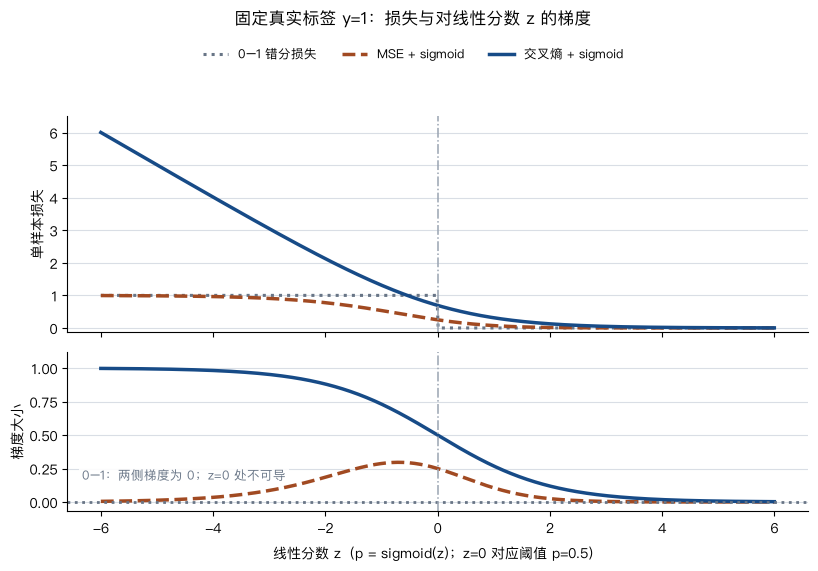

自信错分端 z=-6、p=0.0025：|dℓ_MSE/dz|=0.0049，|dℓ_CE/dz|=0.9975


In [15]:
z_loss = np.linspace(-6, 6, 600)
p_loss = 1 / (1 + np.exp(-z_loss))

# 固定 y=1：z<0 时预测为 0，产生一次错分。
loss_01 = (z_loss < 0).astype(float)
loss_mse = (p_loss - 1) ** 2
loss_ce = np.logaddexp(0, -z_loss)  # -log(sigmoid(z))，稳定计算

grad_mse = np.abs(2 * (p_loss - 1) * p_loss * (1 - p_loss))
grad_ce = np.abs(p_loss - 1)

fig, (ax_loss, ax_grad) = plt.subplots(
    2, 1, figsize=(8.2, 5.9), sharex=True,
    gridspec_kw={"height_ratios": [1.15, 0.85]},
)
colors = {"zero_one": "#687586", "mse": "#A14A22", "ce": "#174B87"}
ax_loss.plot(z_loss, loss_01, color=colors["zero_one"], linestyle=":", linewidth=2.2,
             label="0–1 错分损失")
ax_loss.plot(z_loss, loss_mse, color=colors["mse"], linestyle="--", linewidth=2.5,
             label="MSE + sigmoid")
ax_loss.plot(z_loss, loss_ce, color=colors["ce"], linewidth=2.5,
             label="交叉熵 + sigmoid")
ax_loss.set_ylabel("单样本损失")
ax_loss.set_ylim(-0.12, 6.5)
ax_grad.plot(z_loss, grad_mse, color=colors["mse"], linestyle="--", linewidth=2.5,
             label="MSE：|dℓ/dz|")
ax_grad.plot(z_loss, grad_ce, color=colors["ce"], linewidth=2.5,
             label="交叉熵：|dℓ/dz|")
ax_grad.axhline(0, color=colors["zero_one"], linestyle=":", linewidth=2,
                label="0–1：两侧梯度为 0")
for ax in (ax_loss, ax_grad):
    ax.axvline(0, color="#9AA4B2", linestyle="-.", linewidth=1.1)
    ax.grid(axis="y", color="#D9DEE5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
ax_grad.text(0.02, 0.2, "0–1：两侧梯度为 0；z=0 处不可导",
             transform=ax_grad.transAxes, color=colors["zero_one"], fontsize=9,
             bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9, "pad": 2})
ax_grad.set_ylabel("梯度大小")
ax_grad.set_xlabel("线性分数 z（p = sigmoid(z)；z=0 对应阈值 p=0.5）", labelpad=8)
ax_grad.set_ylim(-0.07, 1.12)

fig.suptitle("固定真实标签 y=1：损失与对线性分数 z 的梯度", y=0.98)
handles, labels = ax_loss.get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="upper center",
           bbox_to_anchor=(0.5, 0.935), fontsize=9)
fig.tight_layout(rect=[0, 0.02, 1, 0.88], h_pad=1.1)

notebook_dir = Path.cwd() if (Path.cwd() / "helpers").exists() else Path.cwd() / "lessons/04-classification-probability/notebook"
figure_path = notebook_dir.parent / "assets" / "lab04-loss-choice.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

wrong_end = np.argmin(np.abs(z_loss + 6))
print(f"自信错分端 z=-6、p={p_loss[wrong_end]:.4f}："
      f"|dℓ_MSE/dz|={grad_mse[wrong_end]:.4f}，"
      f"|dℓ_CE/dz|={grad_ce[wrong_end]:.4f}")

## 可选附录｜三种分类损失的形状

主课件把分类损失拆成三页。图中同时对照真实标签 `y=1` 与 `y=0`：横轴是模型预测为正类的概率 `p`，真实类别概率分别为 `q=p` 与 `q=1−p`。0–1 损失在阈值处跳变；MSE 是平方差；交叉熵是 `−ln(q)`。这些公式图不使用信用卡样本，也不是模型训练结果。

In [16]:
from pathlib import Path

q = np.linspace(0, 1, 501)
colors = {"zero_one": "#687586", "mse": "#A14A22", "ce": "#174B87"}
notebook_dir = Path.cwd() if (Path.cwd() / "helpers").exists() else Path.cwd() / "lessons/04-classification-probability/notebook"
asset_dir = notebook_dir.parent / "assets"
asset_dir.mkdir(parents=True, exist_ok=True)


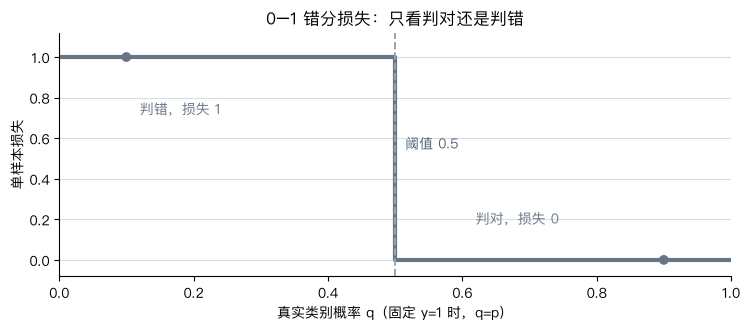

In [17]:
# 1. 错分损失：固定 y=1，q=p；p<0.5 判错，p>=0.5 判对。
loss_01_q = (q < 0.5).astype(float)
fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.step(q, loss_01_q, where="post", color=colors["zero_one"], linewidth=3)
ax.axvline(0.5, color="#9AA4B2", linestyle="--", linewidth=1.4)
ax.scatter([0.1, 0.9], [1, 0], color=[colors["zero_one"]]*2, zorder=3)
ax.text(0.12, 0.72, "判错，损失 1", color=colors["zero_one"])
ax.text(0.62, 0.18, "判对，损失 0", color=colors["zero_one"])
ax.text(0.515, 0.55, "阈值 0.5", color="#52657A", fontsize=10)
ax.set(xlim=(0, 1), ylim=(-0.08, 1.12), xlabel="真实类别概率 q（固定 y=1 时，q=p）", ylabel="单样本损失", title="0–1 错分损失：只看判对还是判错")
ax.grid(axis="y", color="#D9DEE5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(asset_dir / "lab04-loss-01.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


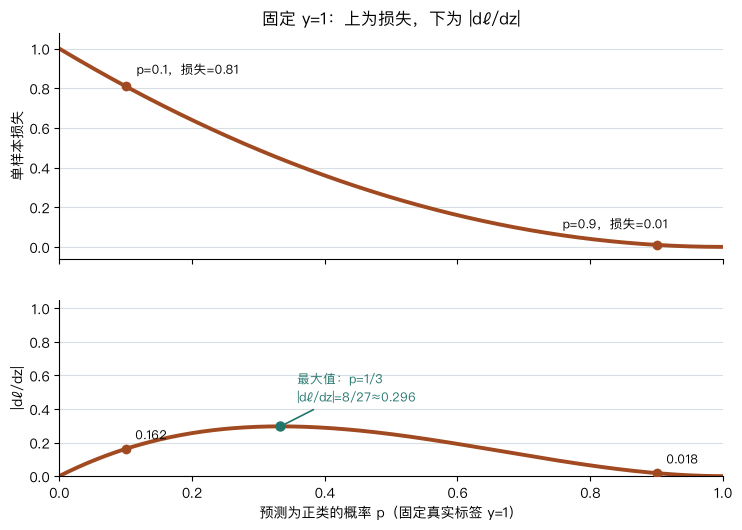

In [18]:
# 2. MSE：同一张图对照损失与传回线性分数 z 的梯度大小（固定 y=1，q=p）。
loss_mse_q = (q - 1) ** 2
grad_mse_q = 2 * q * (1 - q) ** 2
p_grad_max = 1 / 3
grad_max = 8 / 27
fig, (ax_loss, ax_grad) = plt.subplots(2, 1, figsize=(7.6, 5.4), sharex=True, gridspec_kw={"height_ratios": [1, 0.78]})
ax_loss.plot(q, loss_mse_q, color=colors["mse"], linewidth=2.8)
ax_grad.plot(q, grad_mse_q, color=colors["mse"], linewidth=2.8)
ax_grad.scatter([p_grad_max], [grad_max], color="#23756C", s=42, zorder=4)
ax_grad.annotate("最大值：p=1/3\n|dℓ/dz|=8/27≈0.296", (p_grad_max, grad_max), xytext=(12, 18), textcoords="offset points", color="#23756C", fontsize=9, arrowprops={"arrowstyle": "-", "color": "#23756C", "lw": 1.2})
for qi in (0.1, 0.9):
    li = (qi - 1) ** 2
    gi = 2 * qi * (1 - qi) ** 2
    ax_loss.scatter([qi], [li], color=colors["mse"], zorder=3)
    ax_loss.annotate(f"p={qi:.1f}，损失={li:.2f}", (qi, li), xytext=(8, 9 if qi < 0.5 else 12), textcoords="offset points", ha="left" if qi < 0.5 else "right", fontsize=9)
    ax_grad.scatter([qi], [gi], color=colors["mse"], zorder=3)
    ax_grad.annotate(f"{gi:.3f}", (qi, gi), xytext=(7, 7), textcoords="offset points", fontsize=9)
ax_loss.set(ylim=(-0.06, 1.08), ylabel="单样本损失", title="固定 y=1：上为损失，下为 |dℓ/dz|")
ax_grad.set(xlim=(0, 1), ylim=(0, 1.05), xlabel="预测为正类的概率 p（固定真实标签 y=1）", ylabel="|dℓ/dz|")
for ax in (ax_loss, ax_grad):
    ax.grid(axis="y", color="#D9DEE5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(h_pad=2.6)
fig.savefig(asset_dir / "lab04-loss-mse.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

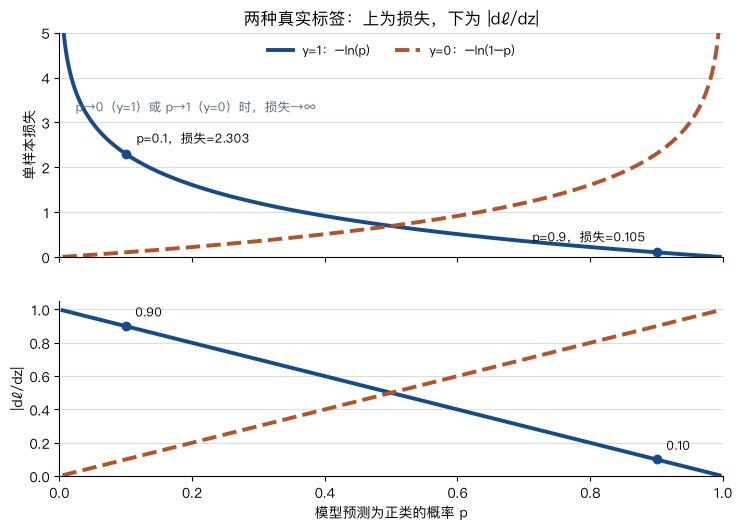

In [19]:
# 3. 交叉熵：同时展示 y=1（q=p）与 y=0（q=1-p）。
q_ce = np.linspace(0.005, 0.995, 600)
loss_ce_q = -np.log(q_ce)
grad_ce_q = 1 - q_ce
loss_ce_y0 = -np.log1p(-q_ce)
grad_ce_y0 = q_ce
fig, (ax_loss, ax_grad) = plt.subplots(2, 1, figsize=(7.6, 5.4), sharex=True, gridspec_kw={"height_ratios": [1, 0.78]})
y0_color = "#B4532A"
ax_loss.plot(q_ce, loss_ce_q, color=colors["ce"], linewidth=2.8, label="y=1：−ln(p)")
ax_loss.plot(q_ce, loss_ce_y0, color=y0_color, linewidth=2.8, linestyle="--", label="y=0：−ln(1−p)")
ax_grad.plot(q_ce, grad_ce_q, color=colors["ce"], linewidth=2.8)
ax_grad.plot(q_ce, grad_ce_y0, color=y0_color, linewidth=2.8, linestyle="--")
for qi in (0.1, 0.9):
    li = -np.log(qi)
    gi = 1 - qi
    ax_loss.scatter([qi], [li], color=colors["ce"], zorder=3)
    ax_loss.annotate(f"p={qi:.1f}，损失={li:.3f}", (qi, li), xytext=(8, 8) if qi < 0.5 else (-8, 8), textcoords="offset points", ha="left" if qi < 0.5 else "right", fontsize=9)
    ax_grad.scatter([qi], [gi], color=colors["ce"], zorder=3)
    ax_grad.annotate(f"{gi:.2f}", (qi, gi), xytext=(7, 7), textcoords="offset points", fontsize=9)
ax_loss.text(0.025, 3.25, "p→0（y=1）或 p→1（y=0）时，损失→∞", color="#52657A", fontsize=9)
ax_loss.set(ylim=(0, 5), ylabel="单样本损失", title="两种真实标签：上为损失，下为 |dℓ/dz|")
ax_grad.set(xlim=(0, 1), ylim=(0, 1.05), xlabel="模型预测为正类的概率 p", ylabel="|dℓ/dz|")
for ax in (ax_loss, ax_grad):
    ax.grid(axis="y", color="#D9DEE5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
ax_loss.legend(frameon=False, loc="upper center", ncol=2, fontsize=9)
fig.tight_layout(h_pad=2.6)
fig.savefig(asset_dir / "lab04-loss-ce.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

In [20]:
# 用有限差分核对两种可导损失对 z 的解析导数（y=1，p=0.1）。
y_check = 1.0
p_check = 0.1
z_check = np.log(p_check / (1 - p_check))
eps = 1e-6

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def mse_from_z(z):
    return (sigmoid(z) - y_check) ** 2

def ce_from_z(z):
    return -np.log(sigmoid(z))

mse_analytic = 2 * (p_check - y_check) * p_check * (1 - p_check)
ce_analytic = p_check - y_check
mse_numeric = (mse_from_z(z_check + eps) - mse_from_z(z_check - eps)) / (2 * eps)
ce_numeric = (ce_from_z(z_check + eps) - ce_from_z(z_check - eps)) / (2 * eps)
np.testing.assert_allclose([mse_numeric, ce_numeric], [mse_analytic, ce_analytic], rtol=1e-6)
print(f"y=1, p=0.1：MSE dℓ/dz={mse_analytic:.3f}，交叉熵 dℓ/dz={ce_analytic:.3f}；解析导数与有限差分一致。")


y=1, p=0.1：MSE dℓ/dz=-0.162，交叉熵 dℓ/dz=-0.900；解析导数与有限差分一致。


## 可选附录｜Logistic 回归为什么用 Logistic sigmoid？

广义上，sigmoid 指一类 S 形函数；本课二分类 Logistic 回归采用 Logistic sigmoid。tanh 也是 S 形函数。图中给出 Logistic sigmoid 的中心对称关系 $\sigma(-x)=1-\sigma(x)$，以及两曲线的中心和值域。

对概率 $p$，几率为 $\operatorname{odds}=p/(1-p)$，$\operatorname{logit}(p)=\ln[\operatorname{odds}]$，即几率的自然对数。例如 $p=0.5$ 时 odds=1、logit=0；$p=0.75$ 时 odds=3、logit$\approx1.10$。logit 将 $(0,1)$ 映到全体实数。
对 0/1 标签，常用 Bernoulli 概率模型；令 $\operatorname{logit}(p)$ 随特征线性变化，是它的标准连接方式（canonical link）。这样系数描述 log-odds 的线性变化，再用逆变换 $p=\sigma(z)=1/(1+e^{-z})$ 得到合法概率。Probit 等连接也能用；logit 是常用基准，不是唯一选项。tanh 原始输出含负值，不能直接作为概率；缩放平移为 $[1+\tanh(z/2)]/2$ 后，恰好就是同一个 $\sigma(z)$。这里说明的是 Logistic 回归的建模选择，不表示 Logistic sigmoid 是神经网络所有层里最常用的激活函数。

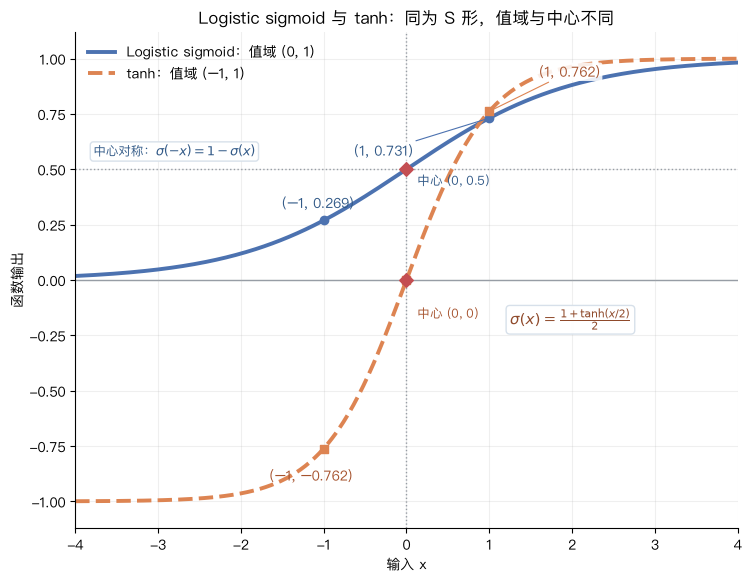

In [21]:
# [ref:sigmoid-tanh-properties]
# 在同一坐标轴比较两种 S 形函数的值域、对称中心和 x=±1 时的函数值。
z_compare = np.linspace(-4, 4, 401)
sigmoid_compare = 1 / (1 + np.exp(-z_compare))
tanh_compare = np.tanh(z_compare)

fig, ax = plt.subplots(figsize=(7.4, 5.7), constrained_layout=True)
ax.plot(z_compare, sigmoid_compare, color="#4C72B0", linewidth=2.8, label="Logistic sigmoid：值域 (0, 1)")
ax.plot(z_compare, tanh_compare, color="#DD8452", linewidth=2.8, linestyle="--", label="tanh：值域 (−1, 1)")
ax.axhline(0, color="#9299A3", linewidth=1, zorder=0)
ax.axhline(0.5, color="#9299A3", linestyle=":", linewidth=1, zorder=0)
ax.axvline(0, color="#9299A3", linestyle=":", linewidth=1, zorder=0)

sigmoid_points = 1 / (1 + np.exp(-np.array([-1, 0, 1])))
tanh_points = np.tanh([-1, 0, 1])
ax.scatter([-1, 0, 1], sigmoid_points, color="#4C72B0", s=36, zorder=3)
ax.scatter([-1, 0, 1], tanh_points, color="#DD8452", marker="s", s=34, zorder=3)
ax.scatter([0, 0], [0.5, 0], marker="D", s=48, color="#C44E52", zorder=4)
ax.annotate("(−1, 0.269)", (-1, sigmoid_points[0]), xytext=(-4, 9), textcoords="offset points", ha="center", color="#315987")
ax.annotate("(−1, −0.762)", (-1, tanh_points[0]), xytext=(-9, -23), textcoords="offset points", ha="center", color="#A6532E")
label_box = {"boxstyle": "round,pad=0.15", "facecolor": "white", "edgecolor": "none", "alpha": 0.88}
ax.annotate("(1, 0.731)", (1, sigmoid_points[2]), xytext=(-76, -27), textcoords="offset points", ha="center", color="#315987", bbox=label_box, arrowprops={"arrowstyle": "-", "color": "#4C72B0", "lw": 0.8})
ax.annotate("(1, 0.762)", (1, tanh_points[2]), xytext=(58, 25), textcoords="offset points", ha="center", color="#A6532E", bbox=label_box, arrowprops={"arrowstyle": "-", "color": "#DD8452", "lw": 0.8})
ax.text(0.13, 0.43, "中心 (0, 0.5)", color="#315987", fontsize=9)
ax.text(0.13, -0.17, "中心 (0, 0)", color="#A6532E", fontsize=9)
formula_box = {"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#D5DFE9", "alpha": 0.94}
ax.text(-3.78, 0.56, r"中心对称：$\sigma(-x)=1-\sigma(x)$", color="#315987", fontsize=9, bbox=formula_box)
ax.text(1.25, -0.20, r"$\sigma(x)=\frac{1+\tanh(x/2)}{2}$", color="#8F4A2B", fontsize=11, bbox=formula_box)
ax.set(title="Logistic sigmoid 与 tanh：同为 S 形，值域与中心不同", xlabel="输入 x", ylabel="函数输出", xlim=(-4, 4), ylim=(-1.12, 1.12))
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

asset_dir = (Path.cwd() if (Path.cwd() / "helpers").exists() else Path.cwd() / "lessons/04-classification-probability/notebook").parent / "assets"
asset_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(asset_dir / "lab04-sigmoid-tanh.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()